Первый кадр статичного видео


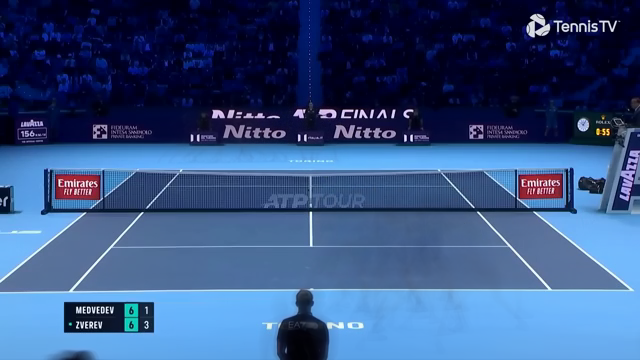

In [8]:
import numpy as np
import cv2, imageio
from google.colab.patches import cv2_imshow

video_path = '/content/tennis_small.mp4'
cap = cv2.VideoCapture(video_path)

frames = []
while True:
  ret, frame = cap.read()
  if not ret:
    break
  frames.append(frame)
cap.release()

h, w = frames[0].shape[:2]

b_frames_matrix = np.zeros((len(frames), h * w), dtype = np.float64)
g_frames_matrix = np.zeros((len(frames), h * w), dtype = np.float64)
r_frames_matrix = np.zeros((len(frames), h * w), dtype = np.float64)

i = 0
for frame in frames:
  b, g, r = cv2.split(frame)
  b = b.reshape(1, -1).astype(np.float64)
  g = g.reshape(1, -1).astype(np.float64)
  r = r.reshape(1, -1).astype(np.float64)

  b_frames_matrix[i] = b
  g_frames_matrix[i] = g
  r_frames_matrix[i] = r
  i += 1

colors_list = []
for color in list([b_frames_matrix, g_frames_matrix, r_frames_matrix]):
    U, s, Vt = np.linalg.svd(color, full_matrices = False)
    s[1:] = 0
    new_color = U @ np.diag(s) @ Vt
    new_color_list = []
    for i in range(len(frames)):
      new_color_list.append(new_color[i].reshape(h, w).clip(0, 255).astype(np.uint8))
    colors_list.append(new_color_list)

background_frames = []

for i in range(len(colors_list[0])):
    b_channel = colors_list[0][i]
    g_channel = colors_list[1][i]
    r_channel = colors_list[2][i]

    frame_bg = cv2.merge([b_channel, g_channel, r_channel])
    background_frames.append(frame_bg)

frames_rgb = []
for frame in background_frames:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frames_rgb.append(frame_rgb)

writer = imageio.get_writer('/content/background_video.mp4', fps = 30, format = 'FFMPEG', codec = 'libx264')

for frame in frames_rgb:
    writer.append_data(frame)
writer.close()

cv2.imwrite('frame_b.png', background_frames[0])
print('Первый кадр статичного видео')
cv2_imshow(background_frames[0])

Первый кадр видео без фона


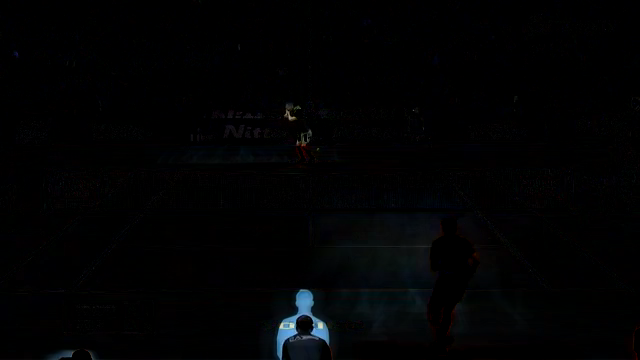

In [7]:
import numpy as np
import cv2
import imageio
from google.colab.patches import cv2_imshow

video_path = '/content/tennis_small.mp4'
cap = cv2.VideoCapture(video_path)

frames = []
while True:
  ret, frame = cap.read()
  if not ret:
    break
  frames.append(frame)
cap.release()

h, w = frames[0].shape[:2]

b_frames_matrix = np.zeros((len(frames), h * w), dtype = np.float64)
g_frames_matrix = np.zeros((len(frames), h * w), dtype = np.float64)
r_frames_matrix = np.zeros((len(frames), h * w), dtype = np.float64)

i = 0
for frame in frames:
  b, g, r = cv2.split(frame)
  b = b.reshape(1, -1).astype(np.float64)
  g = g.reshape(1, -1).astype(np.float64)
  r = r.reshape(1, -1).astype(np.float64)

  b_frames_matrix[i] = b
  g_frames_matrix[i] = g
  r_frames_matrix[i] = r
  i += 1

colors_list = []
for color in list([b_frames_matrix, g_frames_matrix, r_frames_matrix]):
    U, s, Vt = np.linalg.svd(color, full_matrices = False)
    s[0] = 0
    new_color = U @ np.diag(s) @ Vt
    new_color_list = []
    for i in range(len(frames)):
      new_color_list.append(new_color[i].reshape(h, w).clip(0, 255).astype(np.uint8))
    colors_list.append(new_color_list)

without_background_frames = []
for i in range(len(colors_list[0])):
    b_channel = colors_list[0][i]
    g_channel = colors_list[1][i]
    r_channel = colors_list[2][i]

    frame_bg = cv2.merge([b_channel, g_channel, r_channel])
    without_background_frames.append(frame_bg)

frames_rgb = []
for frame in without_background_frames:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frames_rgb.append(frame_rgb)

writer = imageio.get_writer('/content/without_background_video.mp4', fps = 30, format = 'FFMPEG', codec = 'libx264')

for frame in frames_rgb:
    writer.append_data(frame)
writer.close()

cv2.imwrite('frame_wb.png', without_background_frames[0])
print('Первый кадр видео без фона')
cv2_imshow(without_background_frames[0])

Первый кадр исходного видео


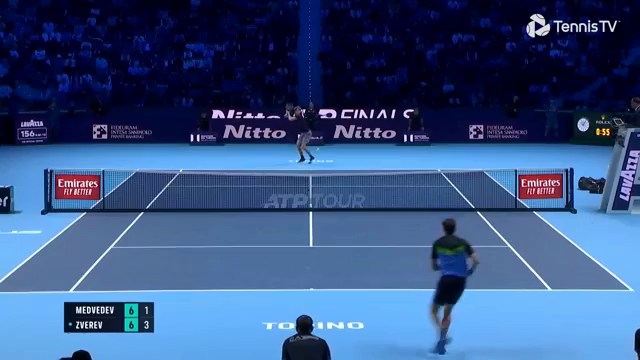

In [9]:
import numpy as np
import cv2
import imageio
from google.colab import files
from google.colab.patches import cv2_imshow

video_path = '/content/tennis_small.mp4'
cap = cv2.VideoCapture(video_path)

frames = []
while True:
  ret, frame = cap.read()
  if not ret:
    break
  frames.append(frame)
cap.release()

cv2.imwrite('frame.png', frames[0])
print('Первый кадр исходного видео')
cv2_imshow(frames[0])